# Emotion Recognition from Speech

## About the Dataset

This project uses the **Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS)**. The dataset contains audio-only speech recordings in `.wav` format by **24 professional actors** (12 male, 12 female), each expressing various emotions.

### Dataset Structure:
- Total files: **1440** (`60 recordings x 24 actors`)
- Each actor is stored in a folder: `Actor_01` to `Actor_24`
- Sampling rate: **48kHz**, 16-bit mono `.wav` files
- Two spoken statements:
  - "Kids are talking by the door"
  - "Dogs are sitting by the door"

### Emotion Labels:
| Code | Emotion     |
|------|-------------|
| 01   | Neutral     |
| 02   | Calm        |
| 03   | Happy       |
| 04   | Sad         |
| 05   | Angry       |
| 06   | Fearful     |
| 07   | Disgust     |
| 08   | Surprised   |

> **Note**: Each emotion is recorded in **normal** and **strong** intensity levels (except neutral, which only has normal).

### File Naming Convention:

Each filename follows this structure:  
`03-01-06-01-02-01-12.wav`  
- Modality: `03` → Audio-only  
- Channel: `01` → Speech  
- Emotion: `06` → Fearful  
- Intensity: `01` → Normal  
- Statement: `02` → "Dogs are sitting by the door"  
- Repetition: `01` → First repetition  
- Actor: `12` → Actor 12 (female, since it's even)

---

## Objective

The objective of this project is to **recognize human emotions from speech audio** using **deep learning techniques**.  
We will:
- Extract features (MFCCs) from audio files.
- Build a CNN/LSTM model to classify emotions.
- Evaluate performance using standard metrics.

## Data Loading

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Emotion label mapping from the filename
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [3]:
# Path to dataset
dataset_path = "audio_speech_actors_01-24"

In [4]:
# Store metadata
file_paths = []
emotions = []
actors = []

In [5]:
for actor_folder in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor_folder)
    
    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            parts = file.split('-')
            emotion_code = parts[2]
            actor_id = parts[-1].split('.')[0]  # e.g., 12 from 03-01-06-01-02-01-12.wav
            
            file_paths.append(os.path.join(actor_path, file))
            emotions.append(emotion_map[emotion_code])
            actors.append(int(actor_id))

In [6]:
# Create DataFrame
df = pd.DataFrame({
    "file_path": file_paths,
    "emotion": emotions,
    "actor": actors
})

In [7]:
# Preview
df.head()

,file_path,emotion,actor
0,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral,1
1,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral,1
2,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral,1
3,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral,1
4,audio_speech_actors_01-24\Actor_01\03-01-02-01...,calm,1


In [8]:
df.shape # 24 Actor * 60 Record

(1440, 3)

Text(0.5, 1.0, 'Emotion Class Distribution')

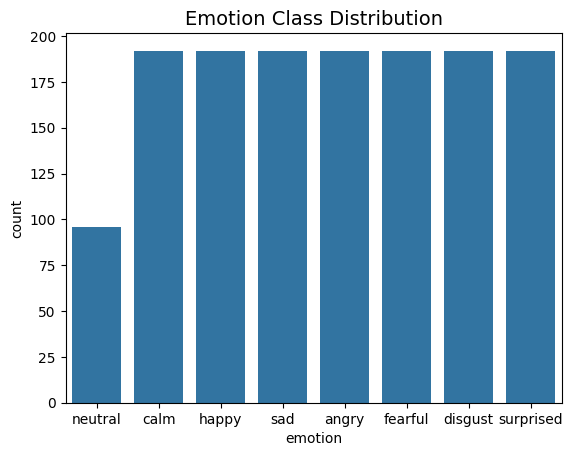

In [9]:
sns.countplot(data=df, x='emotion')
plt.title("Emotion Class Distribution", fontsize=14)

## Data Preprocessing

### Extract Features with Augmentation from Audio

#### Load Audio Files:
- Uses librosa to load each .wav file from the dataset with a sample rate of 22050 Hz.

#### Apply Augmentations:
- Generates 5 versions of the audio using:
    - Original signal
    - Pitch shifting
    - Additive noise
    - Time stretching
    - Volume increase

#### Extract Features:
- For each augmented signal, it extracts:
    - MFCC (Mel-frequency cepstral coefficients)
    - Chroma (pitch class)
    - Spectral contrast
    - Tonnetz (tonal centroid)

#### Stack & Store:
- Combines these into a feature matrix ((time, features)) and appends to a list.

#### Pad & Reshape:
- Pads all feature matrices to match the length of the longest sequence.
- Reshapes the result to 4D tensor: (samples, time, features, 1) — suitable for CNN input.

In [10]:
import librosa
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings("ignore")

In [11]:
MIN_SIGNAL_LENGTH = 1024  # samples

def extract_features(file_path, sr=22050, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=sr)

        if len(y) < MIN_SIGNAL_LENGTH:
            return None

        augmented_signals = [
            y,
            librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2),
            y + 0.005 * np.random.randn(len(y)),
            librosa.effects.time_stretch(y, rate=1.1),
            y * 1.5
        ]

        features_all = []
        for signal in augmented_signals:
            if len(signal) < MIN_SIGNAL_LENGTH:
                continue

            n_fft = min(1024, len(signal))
            if n_fft < 512:
                continue

            hop_length = max(256, n_fft // 2)

            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
            chroma = librosa.feature.chroma_stft(y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length)
            contrast = librosa.feature.spectral_contrast(y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length)

            try:
                tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(signal), sr=sr)
            except:
                tonnetz = np.zeros((6, mfcc.shape[1]))

            feature = np.vstack([mfcc, chroma, contrast, tonnetz])
            features_all.append(feature.T)

        return features_all if features_all else None

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# def extract_features(file_path, sr=22050, n_mfcc=40):
#     try:
#         y, sr = librosa.load(file_path, sr=sr)

#         augmented_signals = [
#             y,
#             librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2),
#             y + 0.005 * np.random.randn(len(y)),
#             librosa.effects.time_stretch(y, rate=1.1),
#             y * 1.5
#         ]

#         features_all = []
#         for signal in augmented_signals:
#             mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
#             chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
#             contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
#             tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(signal), sr=sr)
#             feature = np.vstack([mfcc, chroma, contrast, tonnetz])
#             features_all.append(feature.T)

#         return features_all
#     except Exception as e:
#         print(f"Error processing {file_path}: {e}")
#         return None

In [11]:
X = []
y = []
print("Extracting features...")
for i in tqdm(range(len(df))):
    extracted = extract_features(df.iloc[i]['file_path'])
    if extracted:
        for feat in extracted:
            X.append(feat)
            y.append(df.iloc[i]['emotion'])

Extracting features...


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [46:07<00:00,  1.92s/it]


In [12]:
# Pad sequences and reshape
max_len = max([x.shape[0] for x in X])
X = pad_sequences(X, maxlen=max_len, dtype='float32', padding='post')
X = np.array(X)[..., np.newaxis]  # shape: (samples, time, n_mfcc, 1)
y = np.array(y)

print("Shape of X:", X.shape)
print("Sample emotion labels:", y[:5])

Shape of X: (7200, 228, 65, 1)
Sample emotion labels: ['neutral' 'neutral' 'neutral' 'neutral' 'neutral']


In [13]:
# Save
np.savez_compressed("features_data.npz", X=X, y=y)

In [12]:
data = np.load("features_data.npz")
X = data['X']
y = data['y']

### Labe Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder
import pickle

In [14]:
# Encode labels
LE = LabelEncoder()
y_encoded = LE.fit_transform(y)

In [15]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(LE, f)

### Handel Imbalance 

In [16]:
from sklearn.utils import class_weight

In [17]:
# Compute class weights using encoded labels
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights)}

### Splitting

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Split into train, val, test (80/10/10)
X_train, X_temp, y_train_enc, y_temp_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val_enc, y_test_enc = train_test_split(
    X_temp, y_temp_enc, test_size=0.5, random_state=42, stratify=y_temp_enc
)

In [20]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5760, 228, 65, 1)
X_val shape: (720, 228, 65, 1)
X_test shape: (720, 228, 65, 1)


### One-hot Encoding

In [21]:
from tensorflow.keras.utils import to_categorical

In [22]:
y_train = to_categorical(y_train_enc)
y_val = to_categorical(y_val_enc)
y_test = to_categorical(y_test_enc)

In [23]:
num_classes = y_train.shape[1]

print("y_train shape:", y_train.shape)
print("y_train shape:", y_val.shape)
print("y_train shape:", y_test.shape)
print("Number of classes:", num_classes)  # len(LE.classes_)
print("Classes:", LE.classes_)

y_train shape: (5760, 8)
y_train shape: (720, 8)
y_train shape: (720, 8)
Number of classes: 8
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## Modeling (CNN + BiLSTM + Attention)
- **CNN layers**: extract spatial features from spectrograms (frequency patterns).
- **BatchNormalization & Dropout**: stabilize and regularize training.
- **Reshape**: layer flattens convolutional outputs for RNN compatibility.
- **Bidirectional LSTM**: captures temporal patterns in both directions.
- **Custom Attention Block**: helps the model focus on important time steps.
- **Dense Layers**: transform extracted features for final emotion classification.
- **Softmax Output**: gives a probability distribution over emotion classes.
- **ModelCheckpoint**: saves the best model based on validation loss.
- **EarlyStopping & ReduceLROnPlateau**: help avoid overfitting and tune learning rate dynamically.

### Model Building

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2

In [25]:
# 7. Model: CNN + BiLSTM + Custom Attention
def attention_block(inputs):
    attention = Dense(inputs.shape[-1], activation='softmax')(inputs)
    return Multiply()([inputs, attention])

input_shape = (X.shape[1], X.shape[2], 1)
input_layer = Input(shape=input_shape)

x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(input_layer)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Reshape((x.shape[1], -1))(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = attention_block(x)
x = LayerNormalization()(x)  # Optional
x = GlobalAveragePooling1D()(x)  # Better than Flatten
x = Dense(128)(x)
x = LeakyReLU()(x)
x = Dropout(0.3)(x)

out = Dense(num_classes, activation='softmax')(x)
model = Model(input_layer, out)


# def attention_block(inputs):
#     attention = Dense(inputs.shape[-1], activation='softmax')(inputs)
#     return Multiply()([inputs, attention])

# input_shape = (X.shape[1], X.shape[2], 1)
# input_layer = Input(shape=input_shape)
# x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(input_layer)
# x = MaxPooling2D((2, 2))(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
# x = MaxPooling2D((2, 2))(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# x = Reshape((x.shape[1], -1))(x)
# x = Bidirectional(LSTM(128, return_sequences=True))(x)
# x = attention_block(x)
# x = Flatten()(x)
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.5)(x)
# out = Dense(num_classes, activation='softmax')(x)

In [26]:
# Compile the model
model.compile(
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    optimizer='adam',
    metrics=['accuracy']
)

In [27]:
# Callbacks
# Save the best model (by val_accuracy)
checkpoint_cb = ModelCheckpoint(
    "speech_emotion_recognition_model.keras", monitor='val_loss', mode='min',
    save_best_only=True, verbose=1
)
# Stop training if no val_accuracy improvement after 10 epochs
earlystop_cb = EarlyStopping(
    monitor='val_loss', mode='min', patience=10, restore_best_weights=True, verbose=1
)
# Reduce LR if val_loss plateaus
lr_cb = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3,
    verbose=1, min_lr=1e-6
)
callbacks = [checkpoint_cb, earlystop_cb, lr_cb]

In [28]:
# model.summary()

### Model Training

In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
90/90 [==============================] - ETA: 0s - loss: 1.9185 - accuracy: 0.2750
Epoch 1: val_loss improved from inf to 2.30876, saving model to speech_emotion_recognition_model.keras
90/90 [==============================] - 16s 81ms/step - loss: 1.9185 - accuracy: 0.2750 - val_loss: 2.3088 - val_accuracy: 0.2083 - lr: 0.0010
Epoch 2/200
90/90 [==============================] - ETA: 0s - loss: 1.6335 - accuracy: 0.4168
Epoch 2: val_loss improved from 2.30876 to 1.90411, saving model to speech_emotion_recognition_model.keras
90/90 [==============================] - 6s 63ms/step - loss: 1.6335 - accuracy: 0.4168 - val_loss: 1.9041 - val_accuracy: 0.3111 - lr: 0.0010
Epoch 3/200
90/90 [==============================] - ETA: 0s - loss: 1.4982 - accuracy: 0.4931
Epoch 3: val_loss improved from 1.90411 to 1.39341, saving model to speech_emotion_recognition_model.keras
90/90 [==============================] - 6s 62ms/step - loss: 1.4982 - accuracy: 0.4931 - val_loss: 1.3934 - va

### Model Evaluation

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
# Plot training history
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [32]:
# Evaluate the model on the test set
def evaluate_model(model, X_test, y_test, label_encoder):
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_true, y_pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

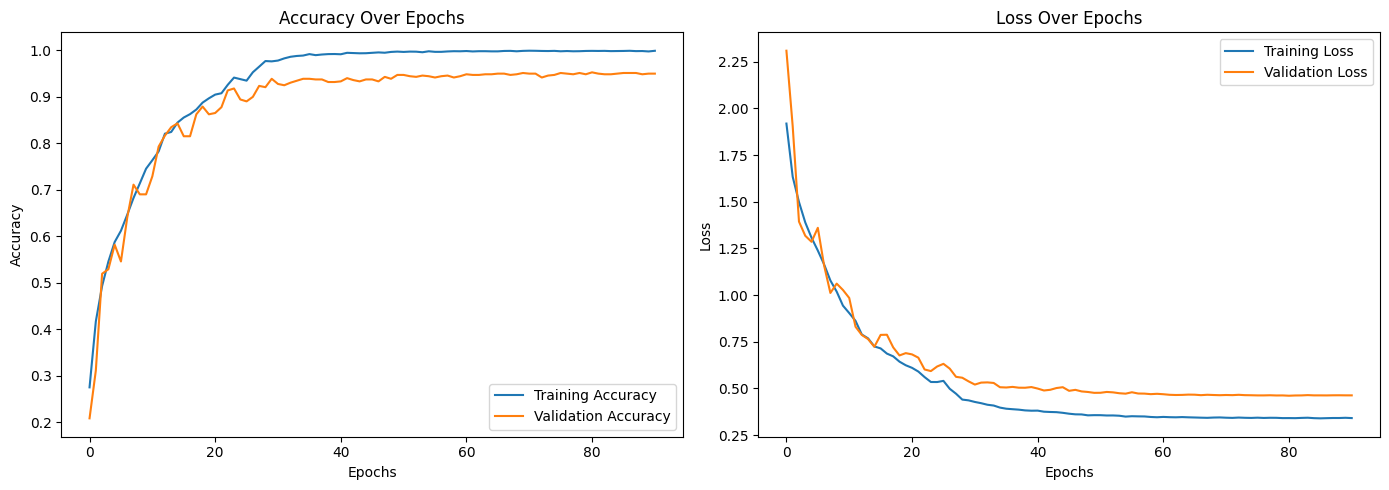

23/23 [==============================] - 1s 16ms/step - loss: 0.4889 - accuracy: 0.9319
Test Accuracy: 93.19%
23/23 [==============================] - 1s 15ms/step

Classification Report:

              precision    recall  f1-score   support

       angry       0.96      0.92      0.94        96
        calm       0.86      0.99      0.92        96
     disgust       0.91      0.95      0.93        96
     fearful       0.92      0.98      0.95        96
       happy       0.97      0.92      0.94        96
     neutral       1.00      0.90      0.95        48
         sad       0.91      0.84      0.88        96
   surprised       0.98      0.95      0.96        96

    accuracy                           0.93       720
   macro avg       0.94      0.93      0.93       720
weighted avg       0.93      0.93      0.93       720



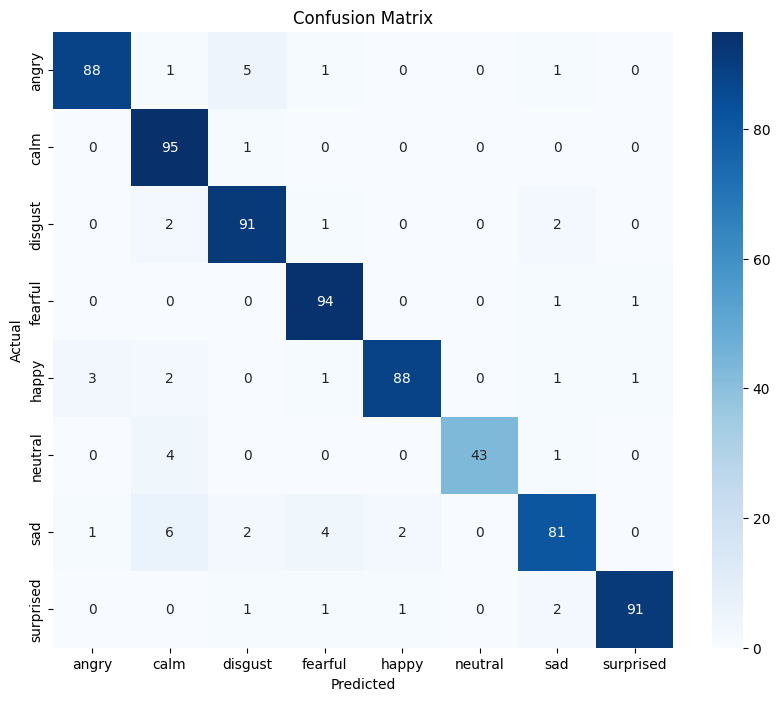

In [33]:
plot_history(history)
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")
evaluate_model(model, X_test, y_test, LE)

### Model Saving

In [34]:
model.save("model.keras", save_format="keras")

### Prediction

In [45]:
import os
import numpy as np
import librosa
from keras.models import load_model
import pickle
from keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from pydub import AudioSegment
import warnings
warnings.filterwarnings("ignore")

In [46]:
# Load your trained model
model = load_model("speech_emotion_recognition_model.keras")

# Load your label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

#### Convert any audio to WAV if needed

In [47]:
def convert_to_wav(input_path, output_path="temp_converted.wav"):
    audio = AudioSegment.from_file(input_path)
    audio = audio.set_channels(1).set_frame_rate(22050)
    audio.export(output_path, format="wav")
    return output_path

#### Extract features from the WAV file

In [52]:
MAX_LEN = X.shape[1]
print("MAX_LEN used in training:", MAX_LEN)

MAX_LEN used in training: 228


In [53]:
MAX_LEN = 228

def extract_single_feature(file_path, sr=22050, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=sr)

        # Skip too short inputs (less than 1024 samples)
        if len(y) < 1024:
            print(f"⚠️ Skipped too-short input for prediction: {file_path}")
            return None

        n_fft = min(1024, len(y))
        if n_fft < 512:
            return None

        hop_length = max(256, n_fft // 2)

        # Extract features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)

        # Tonnetz may fail on some signals
        try:
            tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        except:
            tonnetz = np.zeros((6, mfcc.shape[1]))

        # Stack all features
        feature = np.vstack([mfcc, chroma, contrast, tonnetz]).T

        # Pad to match training input shape
        feature = pad_sequences([feature], maxlen=MAX_LEN, dtype='float32', padding='post')
        feature = feature[..., np.newaxis]  # Add channel dimension

        return feature

    except Exception as e:
        print(f"❌ Error extracting feature: {e}")
        return None

#### Full prediction pipeline

In [49]:
def predict_emotion(audio_path):
    try:
        print("📂 Converting to WAV...")
        wav_path = convert_to_wav(audio_path)

        print("🎧 Extracting features...")
        feature = extract_single_feature(wav_path)

        if feature is not None:
            print("🤖 Predicting...")
            prediction = model.predict(feature)
            predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
            print("🎯 Predicted Emotion:", predicted_label[0])
            return predicted_label[0]
        else:
            print("❌ Failed to extract features.")
            return None
    except Exception as e:
        print("❌ Error in prediction pipeline:", e)
        return None

In [58]:
# Replace with your actual file (e.g., .mp3, .m4a, .wav, etc.)
audio_file = "D:/Learn/Summer Tasks/CodeAlpha/Task 2/test/my_voice4.m4a"
predict_emotion(audio_file)

📂 Converting to WAV...
🎧 Extracting features...
🤖 Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🎯 Predicted Emotion: calm


'calm'